## Clusters

### Climate clusters

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import plotly.express as px

from urllib.request import urlopen
import json

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras import layers, Model

import geopandas as gpd

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#### Data preprocessing

In [3]:
data = pd.read_csv('data/climate.csv')
cols = ['t_mean', 'rh_mean'] # Subset of variables
data['week_end'] = pd.to_datetime(data['week_end'])

In [4]:
data_list = []
geoids = []
for geoid, group in data.groupby('geoid'):
    data_list.append(group[cols].values)
    geoids.append(geoid)
X = np.array(data_list)

n_counties, n_weeks, n_features = X.shape
X_reshaped = X.reshape(-1, n_features)

scaler = StandardScaler()
X_scaled_flat = scaler.fit_transform(X_reshaped)

X_train = X_scaled_flat.reshape(n_counties, n_weeks, n_features)
X_scaled = X_train.reshape(n_counties, -1)

print(f"Final shape for LSTM: {X_train.shape}") 

Final shape for LSTM: (3211, 157, 2)


#### Autoencoder

In [ ]:
# Configuración
latent_dim = 16
timesteps = X_train.shape[1]
features = X_train.shape[2]

# --- ENCODER ---
inputs = layers.Input(shape=(timesteps, features))
h = layers.LSTM(64, activation='tanh', return_sequences=True)(inputs)
latent_vector = layers.LSTM(latent_dim, activation='tanh', return_sequences=False)(h)

encoder_model = Model(inputs, latent_vector, name="Encoder")

# --- DECODER ---
decoder_input = layers.RepeatVector(timesteps)(latent_vector)
h_dec = layers.LSTM(64, activation='tanh', return_sequences=True)(decoder_input)
output = layers.TimeDistributed(layers.Dense(features))(h_dec)

# --- AUTOENCODER COMPLETO ---
autoencoder = Model(inputs, output, name="Autoencoder")
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='mse')

autoencoder.summary()

In [ ]:
# Entrenamiento
autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, validation_split=0.1)

# Generation of vectors for clustering
latent_features = encoder_model.predict(X_train)

In [ ]:
# Save encoder model
encoder_model.save("models/encoder_vanilla_16.keras")

In [16]:
# Load saved encoder
encoder = tf.keras.models.load_model("models/encoder_vanilla_16.keras")

# Generation of vectors for clustering
latent_features = encoder.predict(X_train)

101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


#### Clustering

In [6]:
# Kmeans clustering function
def kmeans_clustering(X, n_clusters=5):
    model = KMeans(n_clusters=n_clusters, random_state=0).fit(X)
    print(f"Silhouette score: {silhouette_score(X, model.labels_, metric="euclidean")}")
    return model.labels_

In [7]:
# USA map to color clusters

url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_20m.zip"
usa = gpd.read_file(url)
usa['GEOID'] = usa['GEOID'].astype(str).str.zfill(5)

def eeuu_map(clusters, X_original, var=0, model_name=""):

    warnings.filterwarnings('ignore')

    mean_temp_county = X_original[:, :, var].mean(axis=1)
    
    df_temp = pd.DataFrame({
        'cluster_original': clusters,
        'mean_temp': mean_temp_county
    })
    
    cluster_stats = df_temp.groupby('cluster_original')['mean_temp'].mean().sort_values(ascending=False)
    
    reorder_map = {old_label: i for i, old_label in enumerate(cluster_stats.index)}
    new_clusters = np.array([reorder_map[label] for label in clusters])
    
    n_clusters = len(np.unique(new_clusters))
    df_clusters = pd.DataFrame({'GEOID': geoids, 'cluster_ordenado': new_clusters})
    df_clusters['GEOID'] = df_clusters['GEOID'].astype(str).str.zfill(5)

    map_df = usa.merge(df_clusters, on='GEOID')
    mainland = map_df[~map_df['STUSPS'].isin(['AK', 'HI', 'PR', 'GU', 'VI'])]

    cmap_clima = plt.cm.get_cmap('RdYlBu')

    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    
    mainland.plot(column='cluster_ordenado', 
                  cmap=cmap_clima,
                  categorical=True,
                  legend=True,
                  ax=ax,
                  linewidth=0.1, 
                  edgecolor='white',
                  legend_kwds={'title': "Ranking Térmico\n(0=Más Cálido)", 
                               'loc': 'lower right',
                               'bbox_to_anchor': (1, 0)})

    ax.set_title(f'Mapa de Clusters Climáticos\n{model_name}, K={n_clusters}', fontsize=16)
    ax.axis('off')
    
    plt.show()

    reorder_map = {old_label: i for i, old_label in enumerate(cluster_stats.index)}
    labels_finales = np.array([reorder_map[l] for l in df_temp['cluster_original']])

    return labels_finales


Silhouette score: 0.331108033657074


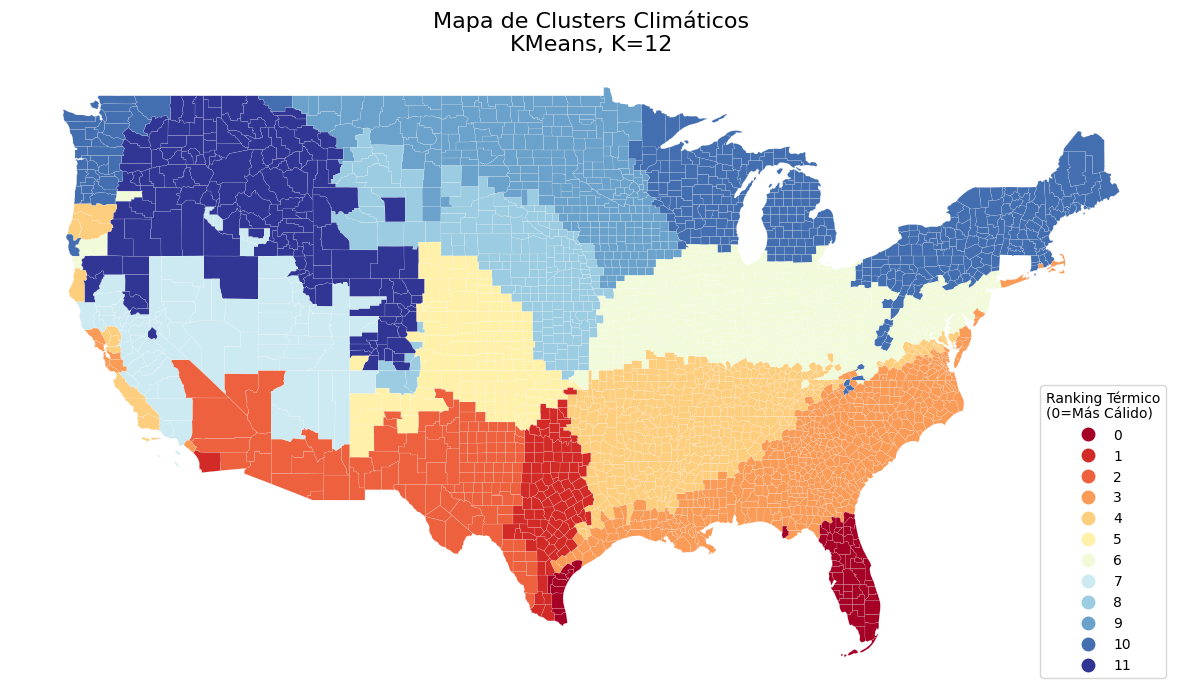

In [13]:
labs = kmeans_clustering(latent_features, n_clusters=12)
labs_reencoded = eeuu_map(labs, X, model_name='KMeans')

In [15]:
climate_mapping = {
    0: "Tropical Humid",
    1: "Warm Temperate / Subtropical Transition",
    2: "Arid Warm (Desert)",
    3: "Warm Temperate Humid (Deep South)",
    4: "Subtropical Humid Atlantic",
    5: "Semiarid Continental",
    6: "Temperate Continental Humid",
    7: "High Altitude Dry Continental",
    8: "Semiarid Cold",
    9: "Cold Continental / Great Lakes",
    10: "Cold Maritime / Pacific Northwest",
    11: "Subarctic Mountain"
}

df_final = pd.DataFrame({
    'geoid': geoids,
    'cluster': labs_reencoded
})

df_final['geoid'] = df_final['geoid'].astype(str).str.zfill(5)
df_final['climate_type'] = df_final['cluster'].map(climate_mapping)

df_final.to_csv('data/climate_clusters.csv', index=False)

### Sociodemographic clusters

In [17]:
df1 = pd.read_csv("data/quickfacts_allus.csv", encoding = "latin1")
df2 = pd.read_csv("data/disabilities_allcounties.csv", encoding = "latin1")

# merging both datasets
for df in [df1, df2]:
    df["county"] = df["county"].astype(str).str.strip().str.lower()
    df["state"] = df["state"].astype(str).str.strip().str.lower()

df2["disability_prevalence"] = df2["disability_prevalence"].astype(str).str.replace("%", "").astype(float)

df = pd.merge(
    df1,
    df2[["county", "state", "disability_prevalence"]],
    on=["county", "state"],
    how="left"
)

In [19]:
# Cleanning of data

# The quality of all the data belonging to Connecticut is not the best, as there are many missing values that cannot be imputated.
df = df[df["state"] != "connecticut"]

df = df.drop(columns= ["county", "state", "population_2024", "education_hsorhigher (25+)", "income_household (2024 dollars)", "age_under5"]) #removing irrelevant variables, and those that would result in high collineality
df = df.rename(columns={"education_bachelorsorhigher (25+)": "education_bachelorsorhigher", "income_percapita (2024 dollars)": "income_percapita", "population_density (square mile 2020)": "population_density"})

#these changes have to do with age variables
df = df.rename(columns={"age_under18": "youth_share", "age_65andover": "elderly_share"})
df["dependency_ratio"] = df["youth_share"] + df["elderly_share"]

#these have to do with racial/ethnic variables
df["minority_share"] = 100- df["race_white"]
df["hispanic_share"] = df["race_hispanicorlatino"]
df = df.drop(columns=["race_white", "race_black", "race_americanindianoralaskanative", "race_asian", "race_nativehawaiianorpacificislander","race_hispanicorlatino"])

#finally, dealing with some missing values.
df["disability_prevalence"] = df["disability_prevalence"].fillna(df["disability_prevalence"].median())
df["without_insuranceunder65"] = df["without_insuranceunder65"].fillna(df["without_insuranceunder65"].median())

#convert object to number
df["population_density"] = pd.to_numeric(
    df["population_density"],
    errors="coerce"
)

In [ ]:
log_vars = ["income_percapita", "population_density", "medianval_ownerunits"]

for col in log_vars:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=True)
        .replace("-", np.nan)
    )

#we want to make sure that all the columns are numeric
    df[col] = pd.to_numeric(df[col], errors="coerce")

#there were a few missing values, which will be replaced with the median
    df[col] = df[col].fillna(df[col].median())

# log tranformation to "balance" numeric values that are not percentages.
    df[col] = np.log1p(df[col])

In [22]:
#normalize data
scaler = MinMaxScaler()
df_final = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

#carry out PCA to reduce dimensionality
pca = PCA(n_components=5)
X_pca = pca.fit_transform(df_final)

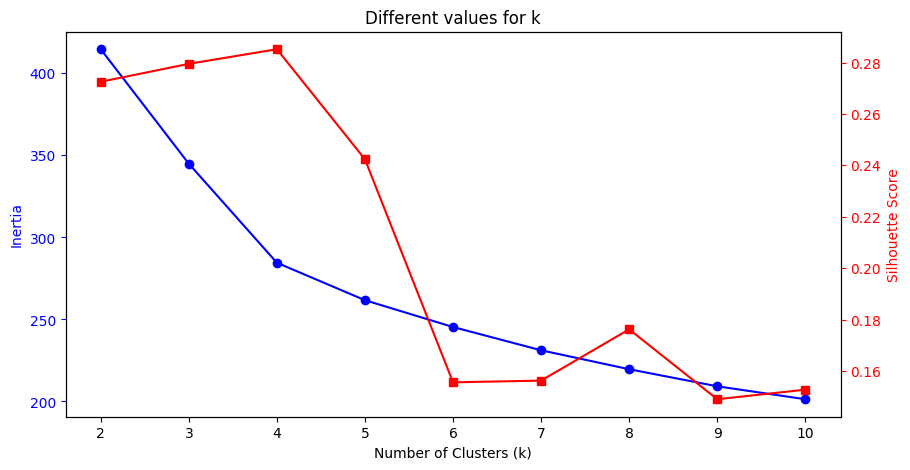

In [23]:
#Evaluating different values for k
inertia = []
silhouette_scores = []
range_diffk = range(2, 11)

for k in range_diffk:
    kmeans_test = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=20,
        max_iter=300,
        random_state=42
    )

    cluster_labels = kmeans_test.fit_predict(df_final)

    inertia.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(df_final, cluster_labels))

#Elbow graph
fig, ax1 = plt.subplots(figsize=(10, 5))

# Eje izquierdo: Inercia (Codo)
ax1.plot(range_diffk, inertia, 'bo-', label='Inercia (Codo)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params('y', colors='b')

# Eje derecho: Silhouette Score
ax2 = ax1.twinx()
ax2.plot(range_diffk, silhouette_scores, 'rs-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params('y', colors='r')

plt.title('Different values for k')
plt.show()

In [26]:
best_k = 4

kmeans_final = KMeans(
    n_clusters=best_k,
    init='k-means++',
    n_init=50,
    max_iter=500,
    random_state=42
)

df["cluster_kmeans"] = kmeans_final.fit_predict(df_final)

### Economic cluster

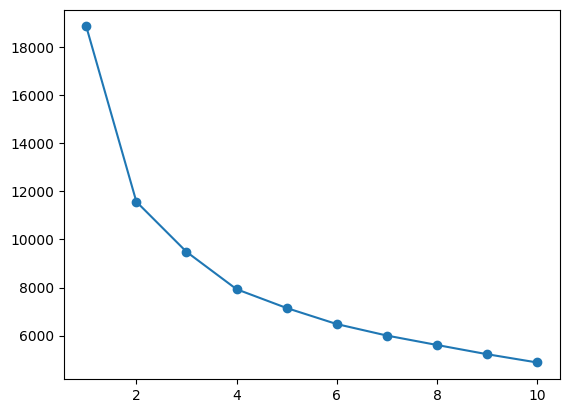

In [ ]:
# read data
df = pd.read_excel("data/df_econ.xlsx", dtype={"FIPS": str})

# change scale
df['Log_Population'] = np.log1p(df['Population_2020'])
df['Log_Establishments'] = np.log1p(df['Establishment_Count'])

# select features
features = ['Poverty_Rate', 'Household_Income', 'Log_Population',
                'RUCC_2023', 'Log_Establishments', 'Average_Weekly_Wage']

# normalize data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])

# elbow plot
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.show()

In [32]:
# clustering

kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['cluster_economico'] = kmeans_final.fit_predict(df_scaled)

resumen_clusters = df.groupby('cluster_economico')[features].mean()

df['cluster_economico'].value_counts()

cluster_economico
0    1348
1    1287
2     508
Name: count, dtype: int64

**Zoom in**

Cluster 0 → rural: high poverty rates, lower incomes, and very isolated areas, but also lower population.

There is low resilience to cope with a wildfire; families do not have savings to survive afterward and would require financial humanitarian support.

Cluster 1 → medium: moderate levels of poverty and wages; middle class.

They have a moderate response capacity and an economy that could withstand temporary impacts.

Cluster 2 → urban

Includes counties with very high business density and large populations, as well as very high salaries.

These are logistical and financial hubs with large companies.

A wildfire here would directly affect the system, although it is interesting to note that such fires may not be very common. The loss of commercial infrastructure would have a major impact at the national level.

## WRVI: Wildfire Risk & Vulnerability Index

In [33]:
import pandas as pd
import numpy as np

from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import os

import us

import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from itertools import combinations

### Climate index

In [38]:
climate_data = pd.read_csv('data/climate.csv')
wrc_df = pd.read_excel('data/wrc_202505.xlsx', sheet_name='Counties')
wrc_df['fips'] = wrc_df['GEOID'].astype(str).str.zfill(5)
bp = 'BP_NATIONAL_RANK'

climate_data['fips'] = climate_data['geoid'].astype(str).str.zfill(5)
climate_data = climate_data[climate_data.columns[4:].to_list()].groupby('fips').mean()

elev = pd.read_csv('data/elevacion_media.csv')
elev['fips'] = elev['geoid'].astype(str).str.zfill(5)
climate_data = pd.merge(climate_data, elev[['fips', 'mean_elev']], on='fips', how='inner')
climate_data = pd.merge(climate_data, wrc_df[['fips', bp]], how='inner', on='fips')
climate_data = climate_data.dropna()

In [ ]:
vars = ['t_mean', 'precip_sum', 'rh_mean', 'd1', 'dsci', 'wind_speed_mean', 'wind_gusts_max', 'wind_direction_dominant', 'mean_elev']
X = climate_data[vars]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
def build_wide_deep_model(input_shape):
    input_layer = layers.Input(shape=(input_shape,))
    
    # Camino Profundo (Deep)
    deep = layers.Dense(128, activation='relu')(input_layer)
    deep = layers.Dense(64, activation='relu')(deep)
    
    # Combinar entrada original (Wide) con salida profunda
    concat = layers.concatenate([input_layer, deep])
    
    # Capas finales
    output = layers.Dense(32, activation='relu')(concat)
    output = layers.Dense(1, activation='sigmoid')(output)
    
    model = models.Model(inputs=input_layer, outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model_wide_deep = build_wide_deep_model(X_scaled.shape[1])

# Entrenamiento con Shuffle
history_wide_deep = model_wide_deep.fit(
    X_scaled, 
    climate_data[bp], 
    epochs=150,
    batch_size=8,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

In [ ]:
from statsmodels.stats.weightstats import ttost_paired

def ttost(df, X, modelo, eps=0.05):

    df['prediccion_rank'] = modelo.predict(X)
    predicho = df['prediccion_rank'].values
    real = df[bp].values

    # Ejecutar el test
    results = ttost_paired(predicho, real, -eps, eps)

    # Desempaquetar según la estructura que mostraste
    p_combined = results[0]
    t_low, p_low, df_low = results[1]
    t_up, p_up, df_up = results[2]

    print(f"--- Análisis de Equivalencia (TOST) ---")
    print(f"Margen de tolerancia (Epsilon): ±{eps}")
    print(f"P-value combinado: {p_combined:.4e}")
    print(f"P-value límite inferior (H0: Diff <= -{eps}): {p_low:.4e}")
    print(f"P-value límite superior (H0: Diff >= {eps}): {p_up:.4e}")

    if p_combined < 0.05:
        print(f"\n✅ RESULTADO: Tu Red Neuronal es ESTADÍSTICAMENTE EQUIVALENTE al BP_NATIONAL_RANK.")
        print(f"La diferencia promedio se mantiene dentro del margen de ±{eps}.")
    else:
        print(f"\n❌ RESULTADO: Los valores NO son equivalentes.")
        print(f"El error del modelo es demasiado grande para el margen de ±{eps}.")

In [ ]:
ttost(climate_data.copy(), X_scaled, model_wide_deep, eps=0.05)

In [ ]:
climate_data['clim_index'] = model_wide_deep.predict(X_scaled)

In [50]:
# MAE
np.abs(climate_data['clim_index']*100 - climate_data[bp]*100).mean()

np.float64(5.657448916221654)

In [47]:
# RMSE
np.sqrt(((climate_data['clim_index']*100 - climate_data[bp]*100) ** 2).mean())

np.float64(8.981319105593908)

In [ ]:
# save model
climate_data[['fips', 'clim_index']].to_csv('data/climate_index.csv', index=False)

### Demographic index

Read data and clean it.

In [79]:
# Read data
demog = pd.read_excel("data/Clusters_Mar18.xlsx", sheet_name= "Unnormalized w. all vars")

# Delete missing values
demog.dropna(inplace=True)

# Generate new columns
demog['minority_share'] = 100 - demog['race_white']
demog['dependency_ratio'] = demog['age_under18'] + demog['age_65andover']

# read fips
fips_url = 'https://www2.census.gov/geo/docs/reference/codes/files/national_county.txt'
fips_df = pd.read_csv(fips_url, header=None, names=['state', 'state_fips', 'county_fips', 'county_name', 'class code'], dtype=str)
fips_df['fips'] = fips_df['state_fips'] + fips_df['county_fips']
fips_df['county_name'] = fips_df['county_name'].str.lower()
fips_df['state_name'] = fips_df['state'].apply(lambda x: us.states.lookup(x).name.lower() if us.states.lookup(x) else None)

# merge demog and fips
demog = pd.merge(fips_df[['fips', 'county_name', 'state_name']], demog, how='inner',
                 left_on=['county_name', 'state_name'], right_on=['county', 'state'])

demog = demog.rename(columns={
    'county': 'county_name',
    'state': 'state_name'
})

# fips manual fix
demog.loc[764, 'fips'] = '46102'
demog.loc[1321, 'fips'] = '35013'
demog.loc[1636, 'fips'] = '29185'
demog.loc[1998, 'fips'] = '22059'
demog.loc[3037, 'fips'] = '02195'
demog.loc[3042, 'fips'] = '02158'
demog.loc[3052, 'fips'] = '02066'
demog.loc[3053, 'fips'] = '02063'
demog.loc[3055, 'fips'] = '02050'
demog.loc[1639, 'fips'] = '29189'
demog = demog.drop(1833)

In [77]:
# Read CDC SVI
cdc = pd.read_csv('data/SVI_2022_US_county.csv')
cdc.rename(columns={'RPL_THEMES': 'overall_index', 'FIPS': 'fips'}, inplace=True)

Model

In [82]:
variables = ['population_2024', 'owneroccupied_units', 'education_hsorhigher (25+)', 'without_insuranceunder65', 'income_household (2024 dollars)', 'minority_share', 'dependency_ratio']

# join data
demog['fips'] = demog['fips'].astype(str)
cdc['fips'] = cdc['fips'].astype(str)
df_final = pd.merge(demog, cdc[['fips', 'overall_index']], on='fips', how='inner')

# normalization
x_final = df_final[variables]
scaler_final = StandardScaler()
x_escalado = scaler_final.fit_transform(x_final)

# apply PCA
pca_final = PCA(n_components=1)
pc1_final = pca_final.fit_transform(x_escalado).flatten()

In [86]:
## Adjust correlation's sign with cdc index

correlacion = np.corrcoef(pc1_final, df_final['overall_index'])[0, 1]

# ajustar el signo
# si la correlación es negativa, invertimos el PC1 para que apunte hacia la vulnerabilidad
if correlacion < 0:
    pc1_final = pc1_final * -1
    correlacion = correlacion * -1

print(f"Final correlation: {correlacion:.4f}")

# final index
# para que sea un score de 0 a 1, usamos el método de percentiles de la cdc
df_final['pca_crudo'] = pc1_final
df_final['demog_index'] = df_final['pca_crudo'].rank(pct=True)

Final correlation: 0.8443


Save model

In [90]:
demog_final_index = df_final[['fips', 'county_name','demog_index']]
demog_final_index.to_csv('data/demog_index.csv', index=False)

### Economic index

In [65]:
# Read data
econ = pd.read_csv("data/economic_clusters.csv")

In [66]:
# Select variables
variables_pca = [
    'Poverty_Rate', 
    'Household_Income', 
    'RUCC_2023',
    'vulnerability_index'
]

In [67]:
# Normalize data
X = econ[variables_pca]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [68]:
# Make PCA and keep first principal component
pca = PCA(n_components=1)
pc1 = pca.fit_transform(X_scaled)

In [73]:
# how much variance is explained by the component?
var = pca.explained_variance_ratio_[0]
print(f"PC1 explains {var:.2%} from variance")

PC1 explains 72.01% from variance


In [ ]:
# Normalize component
minmax = MinMaxScaler(feature_range=(0, 1))
raw_score = minmax.fit_transform(pc1).flatten()

In [74]:
# Correct index if necessary

# if 1 = very vulnerable and 0 = not vulnerable, the score should have a positive correlation with poverty rate
corr_poverty = pd.Series(raw_score).corr(econ['Poverty_Rate'])

if corr_poverty < 0:
    econ['econ_index'] = 1 - raw_score
else:
    econ['econ_index'] = raw_score

In [ ]:
# Save model
econ[['County_Name', 'FIPS', 'econ_index']].to_csv('data/econ_index.csv', index=False)

### WRVI

In [53]:
# Read data
clim_index = pd.read_csv('data/climate_index.csv')
econ_index = pd.read_csv('data/econ_index.csv')
demog_index = pd.read_csv('data/demog_index.csv')

In [ ]:
# Select variables and rename columns
econ_index = econ_index[['FIPS', 'economic_index']]
econ_index.columns = ['fips', 'econ_index']

demog_index = demog_index[['fips', 'demog_index']]
# demog_index.columns = ['fips', 'demog_index']

In [55]:
# merge data
tot = pd.merge(clim_index, econ_index, on='fips', how='inner')
tot = pd.merge(tot, demog_index, on='fips', how='inner')
tot['fips'] = tot['fips'].astype(str).str.zfill(5)

In [56]:
## get shapes

# counties
url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_20m.zip"
usa = gpd.read_file(url)
usa.loc[:, 'fips'] = usa['GEOID'].astype(str).str.zfill(5)

# states
url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_state_5m.zip"
usa_states = gpd.read_file(url)

In [57]:
# function to normalize data
def min_max_scale(col):
    if col.max() == col.min():
        return 0
    return (col - col.min()) / (col.max() - col.min())

In [58]:
# function to color counties with simulated wrvi
def map_score(df, usa, econ_col='econ_index', demog_col='demog_index', clim_col='clim_index', weights=[0.45, 0.35, 0.2]):

    tmp = df.copy()
    
    w_clim, w_econ, w_demog = weights

    tmp.loc[:, 'indice'] = (
        tmp[econ_col] * w_econ +
        tmp[demog_col] * w_demog +
        tmp[clim_col] * w_clim
    )

    tmp.loc[:, 'score'] = min_max_scale(tmp['indice']) * 100

    map_df = usa.merge(tmp, on='fips')

    # Filtrar para el continente (CONUS)
    mainland = map_df[~map_df['STUSPS'].isin(['AK', 'HI', 'PR', 'GU', 'VI'])]
    mainland[['score']].fillna(mainland['score'].mean())

    fig, ax = plt.subplots(1, 1, figsize=(10, 15))

    mainland.plot(column='score', 
                cmap='YlOrRd', 
                legend=True,
                ax=ax,
                vmin=0,
                vmax=100,
                linewidth=0.1,
                edgecolor='0.8',
                legend_kwds={'label': f"WRVI = {w_clim}*climate + {w_demog}*demog + {w_econ}*economy",
                            'orientation': "horizontal",
                            'pad': 0.05})

    ax.set_title('Wildfire Risk & Vulnerability Index (WRVI)', fontsize=16)
    ax.axis('off')
    plt.show()
    

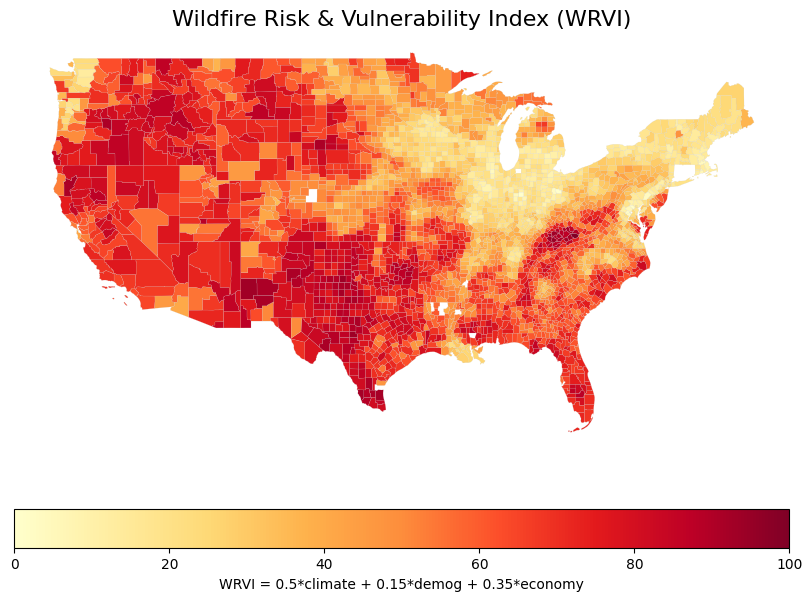

In [59]:
map_score(tot, usa, weights=[0.5, 0.35, 0.15])

In [60]:
# Calculate WRVI
w_clim, w_econ, w_demog = [0.5, 0.35, 0.15]

tot.loc[:, 'score'] = (
    tot['econ_index'] * w_econ +
    tot['demog_index'] * w_demog +
    tot['clim_index'] * w_clim
)

tot.loc[:, 'score'] = min_max_scale(tot['score']) * 100

In [61]:
# Combine data with traversal variables, race-related

demog = pd.read_excel("data/Clusters_Mar18.xlsx", sheet_name= "Unnormalized w. all vars")

fips_url = 'https://www2.census.gov/geo/docs/reference/codes/files/national_county.txt'
fips_df = pd.read_csv(fips_url, header=None, names=['state', 'state_fips', 'county_fips', 'county_name', 'class code'], dtype=str)
fips_df['fips'] = fips_df['state_fips'] + fips_df['county_fips']
fips_df['county_name'] = fips_df['county_name'].str.lower()
fips_df['state_name'] = fips_df['state'].apply(lambda x: us.states.lookup(x).name.lower() if us.states.lookup(x) else None)

demog = pd.merge(fips_df[['fips', 'county_name', 'state_name']], demog, how='inner',
                 left_on=['county_name', 'state_name'], right_on=['county', 'state'])

demog = demog[['fips', 'county', 'state', 'race_white', 'race_black',
               'race_americanindianoralaskanative', 'race_asian',
               'race_nativehawaiianorpacificislander', 'race_hispanicorlatino', 'population_2024']]

tmp = pd.merge(tot, demog, how='inner', on='fips')

index_counties = tmp[['fips', 'county', 'state', 'clim_index', 'econ_index', 'demog_index', 'score', 'race_white',
                      'race_black', 'race_americanindianoralaskanative', 'race_asian',
                      'race_nativehawaiianorpacificislander', 'race_hispanicorlatino', 'population_2024']]
# index_counties.to_csv('data/index_counties.csv', index = False)

In [62]:
# Resume data by state
cols = [col for col in index_counties.columns if col.startswith('race_')]

tmp = index_counties.copy()
for col in cols:
    tmp[f'{col}_counts'] = tmp[col] * tmp['population_2024']

agg_dict = {
    'population_2024': 'sum',
    'clim_index': 'mean',
    'econ_index': 'mean',
    'demog_index': 'mean',
    'score': 'mean'
}

for col in cols:
    agg_dict[f'{col}_counts'] = 'sum'

state_summary = tmp.groupby('state').agg(agg_dict)

for col in cols:
    state_summary[col] = state_summary[f'{col}_counts'] / state_summary['population_2024']

state_summary = state_summary.reset_index()

index_states = state_summary.drop(columns=[f'{col}_counts' for col in cols])
index_states = index_states.drop(columns='population_2024')
index_counties = index_counties.drop(columns='population_2024')
# index_states.to_csv('data/index_states.csv', index = False)

In [63]:
# function to color map per state
def map_state_score(df, usa_states, score_col):
    tmp = df.copy()

    tmp['state_lower'] = tmp['state'].str.lower().str.strip()
    usa_states['NAME_lower'] = usa_states['NAME'].str.lower().str.strip()

    map_df = usa_states.merge(tmp, left_on='NAME_lower', right_on='state_lower', how='left')

    mainland = map_df[~map_df['STUSPS'].isin(['AK', 'HI', 'PR', 'GU', 'VI', 'MP', 'AS'])].copy()

    # mainland[score_col] = mainland[score_col].fillna(mainland[score_col].mean())

    fig, ax = plt.subplots(1, 1, figsize=(15, 10))

    mainland.plot(column=score_col, 
                 cmap='YlOrRd', 
                 legend=True,
                 ax=ax,
                 vmin=0,
                 vmax=100,
                 linewidth=0.5,
                 edgecolor='0.5',
                 legend_kwds={'label': "W-RVI",
                               'orientation': "horizontal",
                               'pad': 0.05})

    ax.set_title('Wildfire Recovery Vulnerability Index (W-RVI) by State', fontsize=18)
    ax.axis('off')
    plt.show()

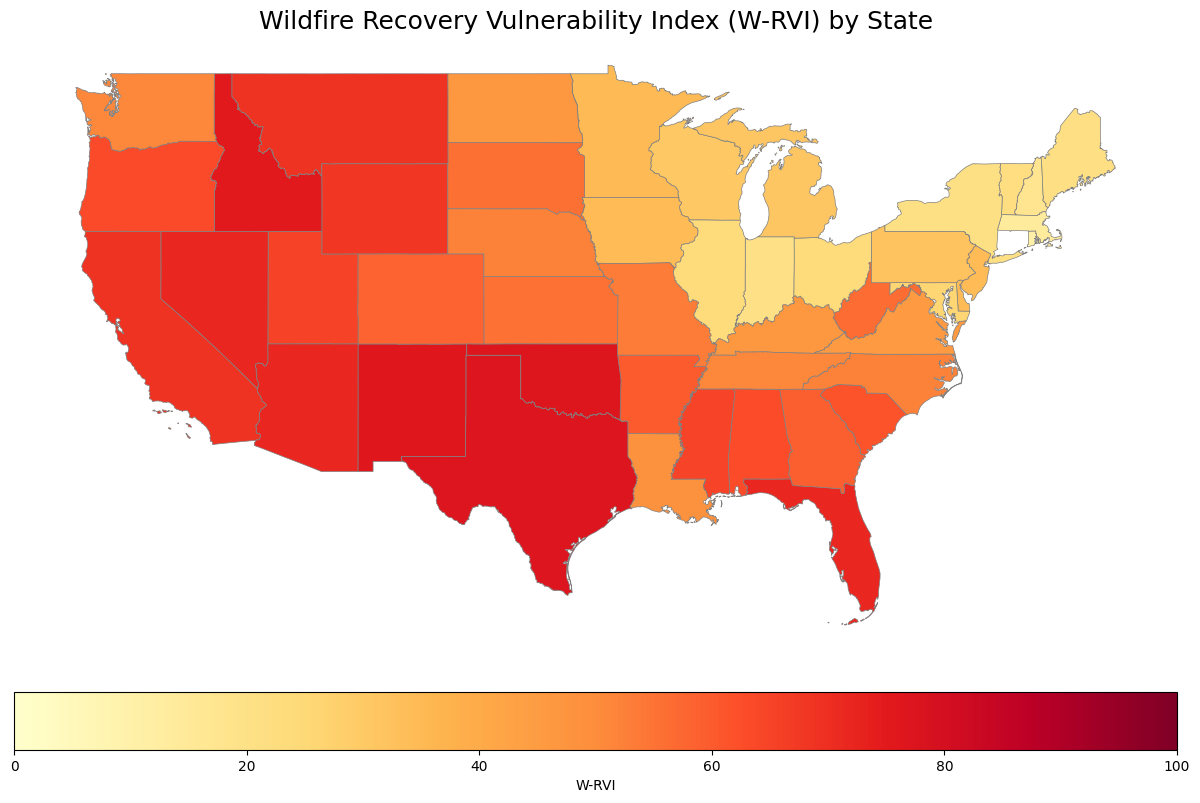

In [64]:
map_state_score(index_states, usa_states, 'score')